Processing 1071 target CSVs from C:\Users\Eef\MY SHIT\Documents\ASTR502spring26\ASTR502spring26\April Fixes\FRIENDS
[OK] 55_Cnc.csv
[OK] BD+20_594.csv
[OK] CoRoT-1.csv
[OK] CoRoT-11.csv
[OK] CoRoT-18.csv
[OK] CoRoT-19.csv
[OK] CoRoT-20.csv
[OK] CoRoT-22.csv
[OK] CoRoT-28.csv
[OK] CoRoT-32.csv
[OK] CoRoT-36.csv
[OK] CoRoT-4.csv
[OK] CoRoT-5.csv
[OK] CoRoT-6.csv
[OK] CoRoT-7.csv
[OK] CoRoT-9.csv
[OK] EPIC_201170410.csv
[OK] EPIC_201238110.csv
[OK] EPIC_201427007.csv
[OK] EPIC_201497682.csv
[OK] EPIC_201595106.csv
[OK] EPIC_201757695.csv
[OK] EPIC_201841433.csv
[OK] EPIC_211945201.csv
[OK] EPIC_212297394.csv
[OK] EPIC_212424622.csv
[OK] EPIC_212499991.csv
[OK] EPIC_212587672.csv
[OK] EPIC_212624936.csv
[OK] EPIC_212737443.csv
[OK] EPIC_220492298.csv
[OK] EPIC_220674823.csv
[OK] EPIC_228836835.csv
[OK] EPIC_229004835.csv
[OK] EPIC_246851721.csv
[OK] EPIC_249893012.csv
[OK] G_9-40.csv
[OK] Gaia-1.csv
[OK] Gaia-2.csv
[OK] GJ_1132.csv
[OK] GJ_1214.csv
[OK] GJ_143.csv
[OK] GJ_238.csv
[OK] GJ_3

C:\Users\Eef\AppData\Local\Temp\ipykernel_286864\1810364029.py:217: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df["is_field_like"] = df["is_field_like"].fillna(False).astype(bool)
C:\Users\Eef\AppData\Local\Temp\ipykernel_286864\1810364029.py:295: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = get_cmap("tab10", len(cluster_names))



Saved summary to: FRIENDS\friends_density_summary.csv
Saved labeled summary to: FRIENDS\friends_density_summary_labeled.csv
Saved failures to: FRIENDS\friends_density_summary_failures.csv

Confirmed cluster targets NOT present in FRIENDS summary:
None

Field-like targets NOT present in FRIENDS summary:
None

Rows available for plotting: 934
Confirmed clusters matched: 12
Field-like matched: 3


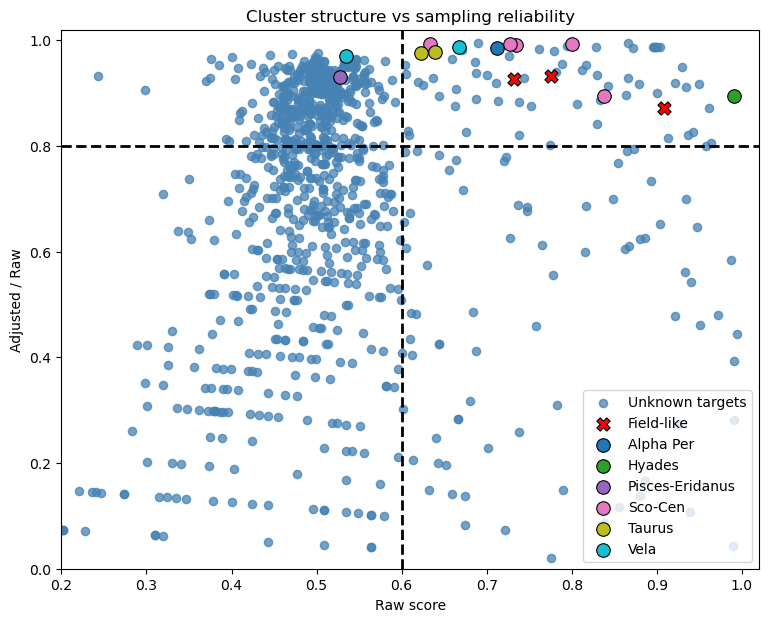


HIGH-CONFIDENCE CANDIDATES:
         target  raw_score  adjusted_score  score_retention reference_label   cluster             model_region
         K2-101   0.903417        0.891750         0.987086         unknown           robust_cluster_candidate
         K2-264   0.900036        0.888524         0.987210         unknown           robust_cluster_candidate
         K2-100   0.898891        0.887500         0.987327         unknown           robust_cluster_candidate
         K2-102   0.897729        0.886433         0.987418         unknown           robust_cluster_candidate
         K2-136   0.991089        0.886016         0.893982         cluster    Hyades robust_cluster_candidate
         K2-104   0.896362        0.885098         0.987434         unknown           robust_cluster_candidate
          K2-95   0.895658        0.884623         0.987679         unknown           robust_cluster_candidate
        TOI-815   0.929132        0.882921         0.950264         unknown        

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from matplotlib.cm import get_cmap


# =========================================================
# helpers
# =========================================================

def normalize_name(s):
    return str(s).strip().replace(" ", "_")


def load_friendfinder_csv(csv_path, required_columns=None):
    if required_columns is None:
        required_columns = ["3D(pc)", "Sep(deg)", "Voff(km/s)"]

    df = pd.read_csv(csv_path)
    df.columns = df.columns.str.strip()

    missing_cols = [col for col in required_columns if col not in df.columns]
    if missing_cols:
        raise ValueError(f"Missing columns in {csv_path.name}: {missing_cols}")

    arrays = {}
    for col in required_columns:
        arrays[col] = pd.to_numeric(df[col], errors="coerce").to_numpy()

    hostname = normalize_name(Path(csv_path).stem)
    return arrays, hostname, df


def load_confirmed_clusters(path):
    df = pd.read_csv(path)
    df.columns = df.columns.str.strip()

    required = ["target", "cluster"]
    missing = [c for c in required if c not in df.columns]
    if missing:
        raise ValueError(f"Missing columns in confirmed cluster file: {missing}")

    df["target"] = df["target"].apply(normalize_name)
    df["cluster"] = df["cluster"].fillna("").astype(str).str.strip()

    if "notes" not in df.columns:
        df["notes"] = ""
    df["notes"] = df["notes"].fillna("").astype(str).str.strip()

    return df


def load_field_like_targets(path):
    path = Path(path)
    if not path.exists():
        return pd.DataFrame(columns=["target", "notes"])

    df = pd.read_csv(path)
    df.columns = df.columns.str.strip()

    if "target" not in df.columns:
        raise ValueError("field_like_targets.csv must contain a 'target' column")

    if "notes" not in df.columns:
        df["notes"] = ""

    df["target"] = df["target"].apply(normalize_name)
    df["notes"] = df["notes"].fillna("").astype(str).str.strip()

    return df[["target", "notes"]]


# =========================================================
# scoring
# =========================================================

def spherical_density_analysis(r_3d, k=10.0):
    r_3d = np.asarray(r_3d, dtype=float)
    r_3d = r_3d[np.isfinite(r_3d)]

    inner_mask = r_3d < 30.0
    outer_mask = (r_3d > 40.0) & (r_3d <= 70.0)

    n_inner = int(np.sum(inner_mask))
    n_outer = int(np.sum(outer_mask))

    v_inner = (4.0 / 3.0) * np.pi * (30.0**3)
    v_outer = (4.0 / 3.0) * np.pi * (70.0**3 - 40.0**3)

    inner_density = n_inner / v_inner
    outer_density = n_outer / v_outer

    if n_inner > 0 and n_outer > 0:
        raw_score = inner_density / (inner_density + outer_density)
        density_ratio = inner_density / outer_density

        inner_weight = n_inner / (n_inner + k)
        outer_weight = n_outer / (n_outer + k)
        confidence_weight = inner_weight * outer_weight

        adjusted_score = raw_score * confidence_weight
        score_retention = adjusted_score / raw_score if raw_score > 0 else np.nan
        score_gap = raw_score - adjusted_score
        score_status = "ok"
    else:
        raw_score = np.nan
        density_ratio = np.nan
        inner_weight = np.nan
        outer_weight = np.nan
        confidence_weight = np.nan
        adjusted_score = np.nan
        score_retention = np.nan
        score_gap = np.nan
        score_status = "insufficient_data"

    return {
        "n_valid_3d": int(len(r_3d)),
        "n_inner_lt_30pc": n_inner,
        "n_outer_40_70pc": n_outer,
        "inner_density": inner_density,
        "outer_density": outer_density,
        "density_ratio": density_ratio,
        "raw_score": raw_score,
        "adjusted_score": adjusted_score,
        "score_gap": score_gap,
        "score_retention": score_retention,
        "inner_weight": inner_weight,
        "outer_weight": outer_weight,
        "confidence_weight": confidence_weight,
        "score_status": score_status,
    }


def summarize_friendfinder_file(csv_path, k=10.0):
    arrays, hostname, df = load_friendfinder_csv(csv_path)
    results = spherical_density_analysis(arrays["3D(pc)"], k=k)

    return {
        "target": hostname,
        "n_rows_in_csv": int(len(df)),
        **results,
        "csv_path": str(Path(csv_path).resolve()),
    }


def summarize_friends_folder(friends_dir, k=10.0):
    friends_dir = Path(friends_dir)

    csv_files = [
        f for f in sorted(friends_dir.glob("*.csv"))
        if "friends_density_summary" not in f.name
    ]

    if not csv_files:
        raise FileNotFoundError(f"No target CSV files found in {friends_dir}")

    rows = []
    failures = []

    print(f"Processing {len(csv_files)} target CSVs from {friends_dir.resolve()}")

    for csv_path in csv_files:
        try:
            row = summarize_friendfinder_file(csv_path, k=k)
            rows.append(row)
            print(f"[OK] {csv_path.name}")
        except Exception as e:
            failures.append({"target": csv_path.stem, "error": repr(e)})
            print(f"[FAIL] {csv_path.name}: {e}")

    summary_df = pd.DataFrame(rows)

    if not summary_df.empty:
        summary_df = summary_df.sort_values(
            by=["score_status", "adjusted_score", "raw_score", "score_retention", "n_inner_lt_30pc"],
            ascending=[True, False, False, False, False],
            na_position="last",
        ).reset_index(drop=True)

    failures_df = pd.DataFrame(failures)
    return summary_df, failures_df


# =========================================================
# labeling
# =========================================================

def apply_reference_labels(summary_df, confirmed_df, field_like_df):
    df = summary_df.copy()
    df["target"] = df["target"].apply(normalize_name)

    # confirmed clusters
    df = df.merge(
        confirmed_df[["target", "cluster", "notes"]],
        on="target",
        how="left",
        suffixes=("", "_cluster"),
    )

    # field-like targets
    field_like_tmp = field_like_df.copy()
    field_like_tmp["is_field_like"] = True

    df = df.merge(
        field_like_tmp[["target", "notes", "is_field_like"]],
        on="target",
        how="left",
        suffixes=("", "_field"),
    )

    df["cluster"] = df["cluster"].fillna("").astype(str).str.strip()
    df["cluster_notes"] = df["notes"].fillna("").astype(str).str.strip()
    df["field_notes"] = df["notes_field"].fillna("").astype(str).str.strip()

    df["is_confirmed_cluster"] = df["cluster"] != ""
    df["is_field_like"] = df["is_field_like"].fillna(False).astype(bool)

    df["reference_label"] = "unknown"
    df.loc[df["is_confirmed_cluster"], "reference_label"] = "cluster"
    df.loc[(~df["is_confirmed_cluster"]) & (df["is_field_like"]), "reference_label"] = "field_like"

    df = df.drop(columns=["notes", "notes_field"], errors="ignore")
    return df

def classify_targets(summary_df, raw_cut=0.6, retention_cut=0.8, adjusted_cut=0.5, diffuse_floor=0.45):
    df = summary_df.copy()

    df["model_region"] = "unknown"

    ok = df["score_status"] == "ok"
    robust = ok & (df["raw_score"] >= raw_cut) & (df["score_retention"] >= retention_cut)
    undersampled = ok & (df["raw_score"] >= raw_cut) & (df["score_retention"] < retention_cut)
    diffuse = ok & (df["raw_score"] >= diffuse_floor) & (df["raw_score"] < raw_cut) & (df["score_retention"] >= retention_cut)
    weak = ok & (df["raw_score"] < diffuse_floor) & (df["score_retention"] >= retention_cut)
    unreliable = ok & (df["score_retention"] < retention_cut) & (df["raw_score"] < raw_cut)

    df.loc[robust, "model_region"] = "robust_cluster_candidate"
    df.loc[undersampled, "model_region"] = "undersampled_high_raw"
    df.loc[diffuse, "model_region"] = "diffuse_association_candidate"
    df.loc[weak, "model_region"] = "field_like_or_off_center"
    df.loc[unreliable, "model_region"] = "weak_and_unreliable"

    low_adjusted = ok & (df["adjusted_score"] < adjusted_cut)
    df.loc[low_adjusted, "model_region"] = df.loc[low_adjusted, "model_region"] + "|adjusted_below_cut"

    return df


# =========================================================
# plotting + reporting
# =========================================================

def plot_structure_vs_reliability(summary_df, raw_cut=0.6, retention_cut=0.8):
    df = summary_df.copy()
    df = df[df["score_status"] == "ok"].copy()
    df = df[np.isfinite(df["raw_score"]) & np.isfinite(df["score_retention"])].copy()

    print("\nRows available for plotting:", len(df))
    print("Confirmed clusters matched:", int(df["is_confirmed_cluster"].sum()))
    print("Field-like matched:", int(df["is_field_like"].sum()))

    plt.figure(figsize=(9, 7))

    # unknown targets
    unknown = df[(~df["is_confirmed_cluster"]) & (~df["is_field_like"])]
    plt.scatter(
        unknown["raw_score"],
        unknown["score_retention"],
        s=35,
        alpha=0.75,
        color="steelblue",
        label="Unknown targets"
    )

    # field-like targets
    field_like = df[df["is_field_like"] & (~df["is_confirmed_cluster"])]
    if not field_like.empty:
        plt.scatter(
            field_like["raw_score"],
            field_like["score_retention"],
            s=90,
            marker="X",
            color="red",
            edgecolors="black",
            linewidths=0.8,
            label="Field-like"
        )

    # confirmed clusters colored by cluster name
    confirmed = df[df["is_confirmed_cluster"]].copy()
    cluster_names = sorted([c for c in confirmed["cluster"].unique() if c != ""])

    if cluster_names:
        cmap = get_cmap("tab10", len(cluster_names))
        for i, cluster_name in enumerate(cluster_names):
            sub = confirmed[confirmed["cluster"] == cluster_name]
            plt.scatter(
                sub["raw_score"],
                sub["score_retention"],
                s=95,
                color=cmap(i),
                edgecolors="black",
                linewidths=0.8,
                label=cluster_name
            )

    plt.axvline(raw_cut, linestyle="--", linewidth=2, color="black")
    plt.axhline(retention_cut, linestyle="--", linewidth=2, color="black")

    plt.xlim(0.2, 1.02)
    plt.ylim(0.0, 1.02)

    plt.xlabel("Raw score")
    plt.ylabel("Adjusted / Raw")
    plt.title("Cluster structure vs sampling reliability")
    plt.legend()
    plt.show()


def print_candidate_lists(summary_df, raw_cut=0.6, retention_cut=0.8):
    df = summary_df.copy()

    good_good = df[
        (df["score_status"] == "ok") &
        (df["raw_score"] >= raw_cut) &
        (df["score_retention"] >= retention_cut)
    ].copy().sort_values("adjusted_score", ascending=False)

    print("\nHIGH-CONFIDENCE CANDIDATES:")
    if good_good.empty:
        print("None")
    else:
        print(good_good[[
            "target", "raw_score", "adjusted_score", "score_retention",
            "reference_label", "cluster", "model_region"
        ]].to_string(index=False))

    likely_misses = df[
        (df["reference_label"] == "cluster") &
        (
            (df["raw_score"] < raw_cut) |
            (df["score_retention"] < retention_cut)
        )
    ].copy().sort_values(["adjusted_score", "raw_score"], ascending=[False, False])

    print("\nCONFIRMED CLUSTERS OUTSIDE TOP-RIGHT REGION:")
    if likely_misses.empty:
        print("None")
    else:
        print(likely_misses[[
            "target", "cluster", "raw_score", "adjusted_score",
            "score_retention", "n_inner_lt_30pc", "n_outer_40_70pc", "model_region"
        ]].to_string(index=False))

    field_intruders = df[
        (df["reference_label"] == "field_like") &
        (df["score_status"] == "ok") &
        (df["raw_score"] >= raw_cut) &
        (df["score_retention"] >= retention_cut)
    ].copy().sort_values("adjusted_score", ascending=False)

    print("\nFIELD-LIKE TARGETS INSIDE TOP-RIGHT REGION:")
    if field_intruders.empty:
        print("None")
    else:
        print(field_intruders[[
            "target", "raw_score", "adjusted_score",
            "score_retention", "model_region"
        ]].to_string(index=False))

    return good_good, likely_misses, field_intruders


# =========================================================
# RUN THIS CELL ANY TIME FRIENDS OR LABEL FILES CHANGE
# =========================================================

friends_dir = Path("FRIENDS")
confirmed_clusters_csv = Path("confirmed_clusters.csv")
field_like_targets_csv = Path("field_like_targets.csv")  # optional

# 1. rebuild summary from scratch
summary_df, failures_df = summarize_friends_folder(friends_dir=friends_dir, k=10.0)

# 2. load labels
confirmed_df = load_confirmed_clusters(confirmed_clusters_csv)
field_like_df = load_field_like_targets(field_like_targets_csv)

# 3. merge labels + classify
summary_df = apply_reference_labels(summary_df, confirmed_df, field_like_df)
summary_df = classify_targets(summary_df, raw_cut=0.6, retention_cut=0.8, adjusted_cut=0.5, diffuse_floor=0.45)

# 4. save fresh outputs
raw_summary_path = friends_dir / "friends_density_summary.csv"
labeled_summary_path = friends_dir / "friends_density_summary_labeled.csv"
failures_path = friends_dir / "friends_density_summary_failures.csv"

summary_df.drop(
    columns=["cluster", "cluster_notes", "field_notes", "is_confirmed_cluster", "is_field_like", "reference_label", "model_region"],
    errors="ignore"
).to_csv(raw_summary_path, index=False)

summary_df.to_csv(labeled_summary_path, index=False)
failures_df.to_csv(failures_path, index=False)

print(f"\nSaved summary to: {raw_summary_path}")
print(f"Saved labeled summary to: {labeled_summary_path}")
print(f"Saved failures to: {failures_path}")

# 5. report targets missing from current FRIENDS summary
friends_targets = set(summary_df["target"])
confirmed_targets = set(confirmed_df["target"])
field_targets = set(field_like_df["target"])

missing_confirmed = sorted(confirmed_targets - friends_targets)
missing_field = sorted(field_targets - friends_targets)

print("\nConfirmed cluster targets NOT present in FRIENDS summary:")
print(missing_confirmed if missing_confirmed else "None")

print("\nField-like targets NOT present in FRIENDS summary:")
print(missing_field if missing_field else "None")

# 6. plot
plot_structure_vs_reliability(summary_df, raw_cut=0.6, retention_cut=0.8)

# 7. print useful lists
good_good_df, confirmed_misses_df, field_intruders_df = print_candidate_lists(
    summary_df, raw_cut=0.6, retention_cut=0.8
)